In [2]:
import pandas as pd
import numpy as np
import sys
import os
from scipy import stats

# Add project root to path
sys.path.append(os.path.abspath(os.path.join('..', '..')))

import util
import plotting.plotting_style as plt
from plotting.plotting_style import rgb

# Load Data
# file_path = '../../data_csv/final_Data_iaaf_scores_neu.csv'
df = util.load_data()

# Parse Dates
def parse_german_date(row):
    date_str = row['datum']
    year_col = row['jahr']
    
    if pd.isna(date_str):
        return pd.NaT
    
    date_str = str(date_str).strip()
    try:
        return pd.to_datetime(date_str, format='%d.%m.%Y')
    except ValueError:
        pass
    try:
        clean_str = date_str.rstrip('.')
        temp_date = pd.to_datetime(clean_str, format='%d.%m')
        return temp_date.replace(year=int(year_col))
    except ValueError:
        return pd.NaT

print("Parsing dates...")
df['parsed_date'] = df.apply(parse_german_date, axis=1)
df['month'] = df['parsed_date'].dt.month
df['day_of_year'] = df['parsed_date'].dt.dayofyear

df_recent = df[df['jahr'] >= 2016].copy()
print(f"Daten geladen: {len(df_recent)} Einträge.")

Parsing dates...


/var/folders/lf/d2nc392142b837mf8sypzlx00000gn/T/ipykernel_43615/569993206.py:33: DeprecationWarning: Parsing dates involving a day of month without a year specified is ambiguous
and fails to parse leap day. The default behavior will change in Python 3.15
to either always raise an exception or to use a different default year (TBD).
To avoid trouble, add a specific year to the input & format.
See https://github.com/python/cpython/issues/70647.
  temp_date = pd.to_datetime(clean_str, format='%d.%m')


Daten geladen: 67189 Einträge.


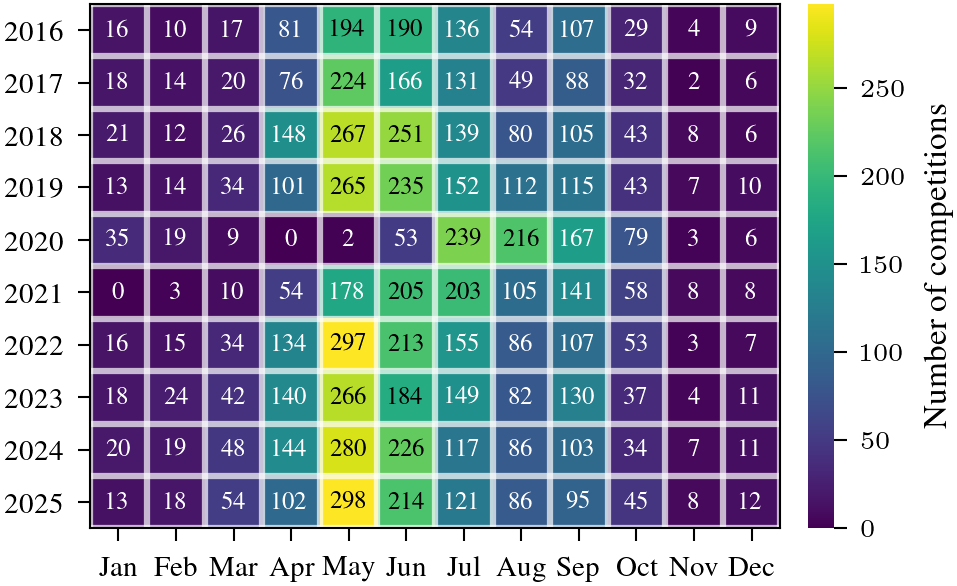

In [4]:
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.ticker as ticker


df_germany = df_recent[~df_recent['ort'].str.contains(r'/[A-Z]{3}', regex=True)].copy()

df_germany['competition_id'] = df_germany['datum'].astype(str) + "_" + df_germany['ort'].astype(str) + "_" + df_germany['jahr'].astype(str)

# Calculate the pivot table for the heatmap (Competitions per month)
activity_pivot = df_germany.pivot_table(
    index='jahr', 
    columns='month', 
    values='competition_id', 
    aggfunc=lambda x: x.nunique(),
    fill_value=0
)

# Group by Day of Year across ALL years
global_stats = df_germany.groupby('day_of_year')['iaaf_score'].median()
global_smoothed = global_stats.rolling(window=14, center=True).mean()


column_width = "half"

with plt.rc_context(plt.bundles.icml2024(column=column_width)):


    years = df_germany['jahr'].unique()

    month_starts = [1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335]
    month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

    heatmap_data = activity_pivot.values

    
    years_idx = activity_pivot.index.values
    months_idx = activity_pivot.columns.values

    cmap_name = 'viridis' 

    im = plt.imshow(heatmap_data, cmap=cmap_name, aspect='auto')

    plt.gca().set_xticks(np.arange(heatmap_data.shape[1] + 1) - 0.5, minor=True)
    plt.gca().set_yticks(np.arange(heatmap_data.shape[0] + 1) - 0.5, minor=True)

    plt.grid(which="minor", color="white", linestyle='-', linewidth=1.5)
    plt.tick_params(which="minor", bottom=False, left=False)

    # Achsen-Labels
    plt.gca().set_xticks(np.arange(len(months_idx)))
    plt.gca().set_xticklabels(month_names, fontsize=7)
    plt.gca().set_yticks(np.arange(len(years_idx)))
    plt.gca().set_yticklabels(years_idx, fontsize=7)

    
    max_val = heatmap_data.max()
    threshold = max_val * 0.6 

    for i in range(len(years_idx)): 
        for j in range(len(months_idx)): 
            val = heatmap_data[i, j]
            
            # Nur anzeigen, wenn Wert vorhanden (> 0), reduziert visuelles Rauschen
            # if val > 0: 
            # Farbe basierend auf Hintergrundhelligkeit wählen
            if cmap_name == 'viridis':
                text_color = "black" if val > threshold else "white"
            elif cmap_name == 'Blues':
                # Bei Blues ist es umgekehrt: Hohe Werte sind dunkelblau
                text_color = "white" if val > threshold else "black"
            else:
                text_color = "white" # Fallback
            
            if column_width == "full":
                plt.text(j, i, str(int(val)), ha="center", va="center", 
                            color=text_color)
            else:
                plt.text(j, i, str(int(val)), ha="center", va="center", 
                            color=text_color, fontsize=6)

    # Colorbar
    cbar = plt.colorbar(im, fraction=0.046, pad=0.04)
    cbar.outline.set_visible(False)
    cbar.set_label('Number of competitions')


    plt.savefig(f"COVID_Heatmap_{column_width}", category="Corona_Analyse")
    plt.show()